In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

In [131]:
train_data = pd.read_csv('adult/adult.data',header = None,names=columns,na_values=[' ?', '?'],skipinitialspace=True)
train_data.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [132]:
test_data = pd.read_csv('adult/adult.test',header = 0,names=columns,na_values=[' ?', '?'],skipinitialspace=True)
test_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


In [133]:
train_data.shape

(32561, 15)

In [134]:
test_data.shape

(16281, 15)

In [135]:
train_data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [136]:
test_data.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [137]:
train_data[train_data.isna().any(axis=1)]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,>50K
27,54,NaN,180211,Some-college,10,Married-civ-spouse,NaN,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,NaN,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,NaN,<=50K
61,32,NaN,293936,7th-8th,4,Married-spouse-absent,NaN,Not-in-family,White,Male,0,0,40,NaN,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,35,NaN,320084,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
32531,30,NaN,33811,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,71,NaN,287372,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
32541,41,NaN,202822,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [138]:
train_data = train_data.dropna().reset_index(drop=True)
test_data = test_data.dropna().reset_index(drop=True)

In [139]:
test_data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [140]:
# Combine train and test data for EDA and preprocessing
df = pd.concat([train_data, test_data], ignore_index=True)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [141]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   fnlwgt          45222 non-null  int64 
 3   education       45222 non-null  object
 4   education-num   45222 non-null  int64 
 5   marital-status  45222 non-null  object
 6   occupation      45222 non-null  object
 7   relationship    45222 non-null  object
 8   race            45222 non-null  object
 9   sex             45222 non-null  object
 10  capital-gain    45222 non-null  int64 
 11  capital-loss    45222 non-null  int64 
 12  hours-per-week  45222 non-null  int64 
 13  native-country  45222 non-null  object
 14  income          45222 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.2+ MB


In [143]:
df['income'].value_counts()

income
<=50K     22654
<=50K.    11360
>50K       7508
>50K.      3700
Name: count, dtype: int64

In [144]:
df['income'] = df['income'].str.replace('.', '', regex=False)
df["income"].value_counts()

income
<=50K    34014
>50K     11208
Name: count, dtype: int64

In [145]:
df['income'] = df['income'].replace({
    '<=50K': 0,
    '>50K': 1,
}).astype(int) 

C:\Users\prash\AppData\Local\Temp\ipykernel_4744\1145146080.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({


In [146]:
df['income'].value_counts()

income
0    34014
1    11208
Name: count, dtype: int64

In [147]:
df['race'].value_counts()

race
White                 38903
Black                  4228
Asian-Pac-Islander     1303
Amer-Indian-Eskimo      435
Other                   353
Name: count, dtype: int64

In [148]:
df['sex'].value_counts()

sex
Male      30527
Female    14695
Name: count, dtype: int64

In [149]:
df['relationship'].value_counts()

relationship
Husband           18666
Not-in-family     11702
Own-child          6626
Unmarried          4788
Wife               2091
Other-relative     1349
Name: count, dtype: int64

In [150]:
df['workclass'].value_counts()

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64

In [151]:
df['marital-status'].value_counts()

marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64

In [152]:
numerical_col = df.select_dtypes(include='number')
numerical_col.head(7)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0
5,37,284582,14,0,0,40,0
6,49,160187,5,0,0,16,0


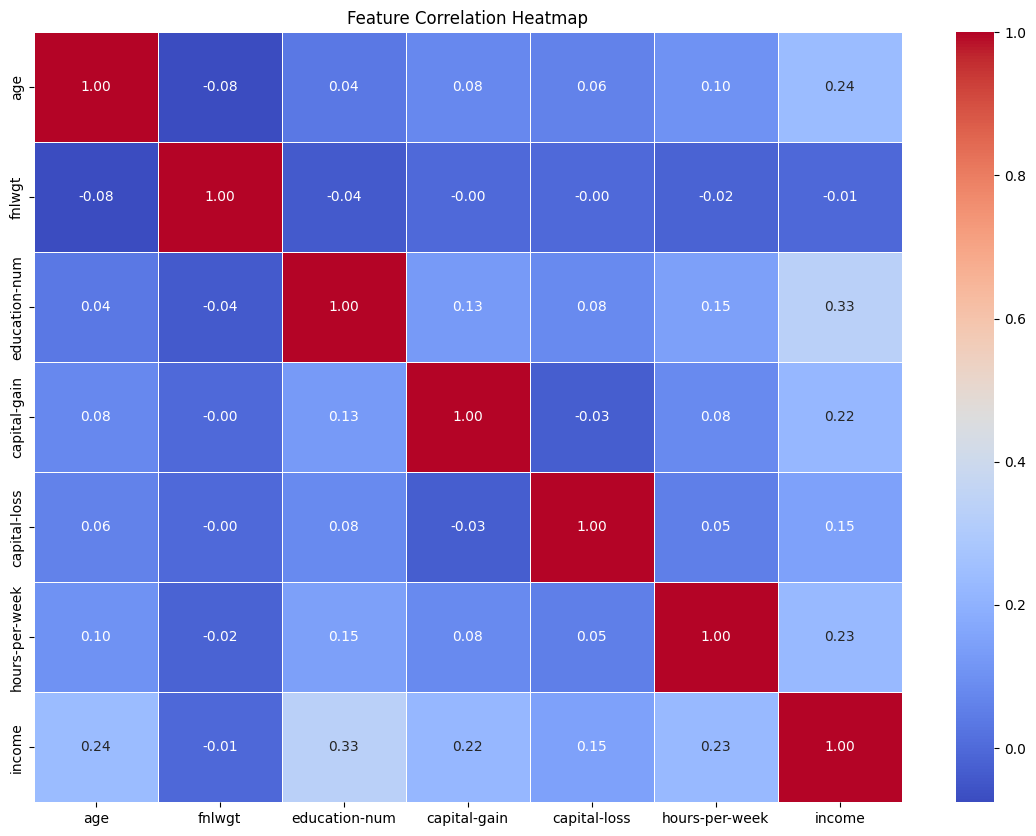

In [153]:
# Plot correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = numerical_col.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Drop education since education-num present, Drop fnlwgt since it represents final weight and we aren't doing weighted analysis

In [154]:
df.drop(columns=['fnlwgt','education'],inplace=True)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education-num   45222 non-null  int64 
 3   marital-status  45222 non-null  object
 4   occupation      45222 non-null  object
 5   relationship    45222 non-null  object
 6   race            45222 non-null  object
 7   sex             45222 non-null  object
 8   capital-gain    45222 non-null  int64 
 9   capital-loss    45222 non-null  int64 
 10  hours-per-week  45222 non-null  int64 
 11  native-country  45222 non-null  object
 12  income          45222 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 4.5+ MB


Encoding

In [156]:
categorical = df.select_dtypes(include='object').columns
categorical

Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object')

In [157]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical:
    df[col] = le.fit_transform(df[col])

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  int64
 2   education-num   45222 non-null  int64
 3   marital-status  45222 non-null  int64
 4   occupation      45222 non-null  int64
 5   relationship    45222 non-null  int64
 6   race            45222 non-null  int64
 7   sex             45222 non-null  int64
 8   capital-gain    45222 non-null  int64
 9   capital-loss    45222 non-null  int64
 10  hours-per-week  45222 non-null  int64
 11  native-country  45222 non-null  int64
 12  income          45222 non-null  int64
dtypes: int64(13)
memory usage: 4.5 MB


In [159]:
df.head(7)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,5,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,13,2,3,0,4,1,0,0,13,38,0
2,38,2,9,0,5,1,4,1,0,0,40,38,0
3,53,2,7,2,5,0,2,1,0,0,40,38,0
4,28,2,13,2,9,5,2,0,0,0,40,4,0
5,37,2,14,2,3,5,4,0,0,0,40,38,0
6,49,2,5,3,7,1,2,0,0,0,16,22,0


In [160]:
X = df.drop(columns='income')
y = df['income']

In [161]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [162]:
y_train.value_counts() # Before SMOTE

income
0    23821
1     7834
Name: count, dtype: int64

In [163]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

c:\Users\prash\anaconda3\envs\gpt2_finetune\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [164]:
y_train.value_counts() # After SMOTE

income
0    23821
1    23821
Name: count, dtype: int64

In [165]:
scaling_col = ['capital-gain','capital-loss','hours-per-week']

In [166]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[scaling_col] = scaler.fit_transform(X_train[scaling_col])
X_test[scaling_col] = scaler.transform(X_test[scaling_col])

In [167]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score, precision_score

In [168]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"{name} Precision: {prec:.4f}")
    print(f"{name} Recall: {rec:.4f}")
    print(f"{name} F1 Score: {f1:.4f}")

    # print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return name, round(acc, 2), round(prec, 2), round(rec, 2), round(f1, 2)

FN in this case, you earn more > $50k but misclassified - This is more costly, high income individuals missed - Missed predictions of people with income > $50k

FP in this case, you earn <= $50k but misclassified


KNN Accuracy: 0.7834
KNN Precision: 0.8074
KNN Recall: 0.7834
KNN F1 Score: 0.7915


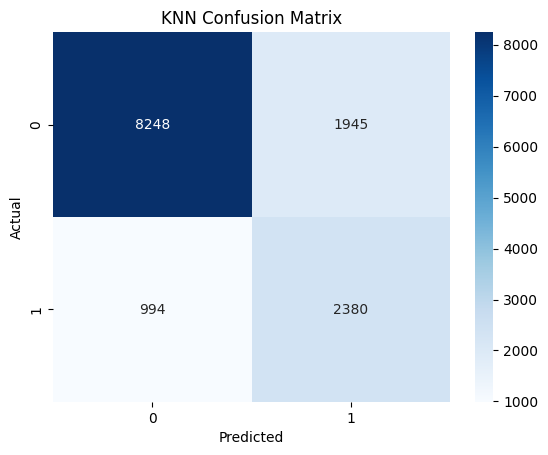


SVM Accuracy: 0.7443
SVM Precision: 0.8143
SVM Recall: 0.7443
SVM F1 Score: 0.7603


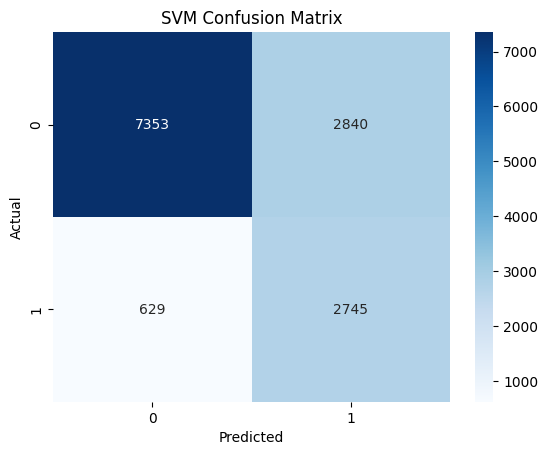


Decision Tree Accuracy: 0.8019
Decision Tree Precision: 0.8141
Decision Tree Recall: 0.8019
Decision Tree F1 Score: 0.8066


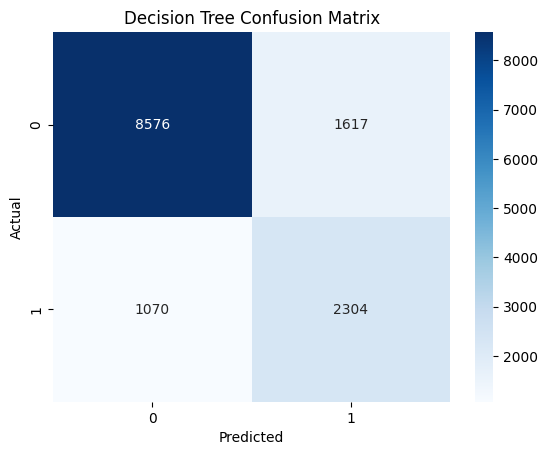


Random Forest Accuracy: 0.8322
Random Forest Precision: 0.8410
Random Forest Recall: 0.8322
Random Forest F1 Score: 0.8356


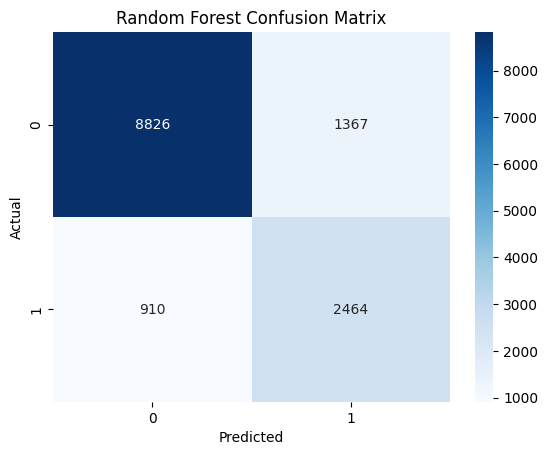


Gradient Boosting Accuracy: 0.8196
Gradient Boosting Precision: 0.8522
Gradient Boosting Recall: 0.8196
Gradient Boosting F1 Score: 0.8281


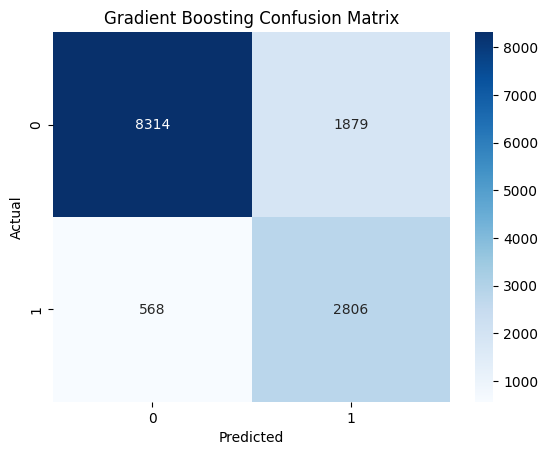


Naive Bayes Accuracy: 0.8146
Naive Bayes Precision: 0.8022
Naive Bayes Recall: 0.8146
Naive Bayes F1 Score: 0.8000


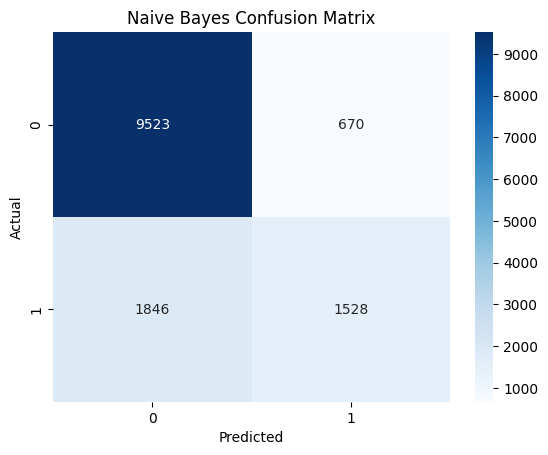

In [169]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

results = []

results.append(evaluate_model('KNN', KNeighborsClassifier()))
results.append(evaluate_model('SVM', SVC()))
results.append(evaluate_model('Decision Tree', DecisionTreeClassifier()))
results.append(evaluate_model('Random Forest', RandomForestClassifier()))
results.append(evaluate_model('Gradient Boosting', GradientBoostingClassifier()))
results.append(evaluate_model('Naive Bayes', GaussianNB()))

# Here, we aimed to decrease the no. of FNs

C:\Users\prash\AppData\Local\Temp\ipykernel_4744\3865556091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x=metric, y='Model', palette='mako')


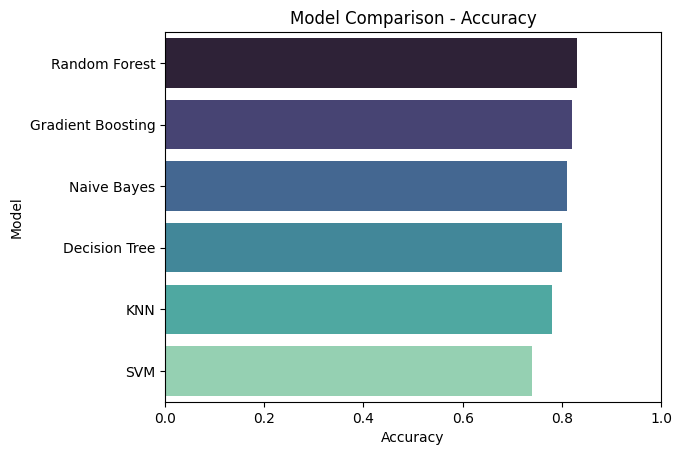

C:\Users\prash\AppData\Local\Temp\ipykernel_4744\3865556091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x=metric, y='Model', palette='mako')


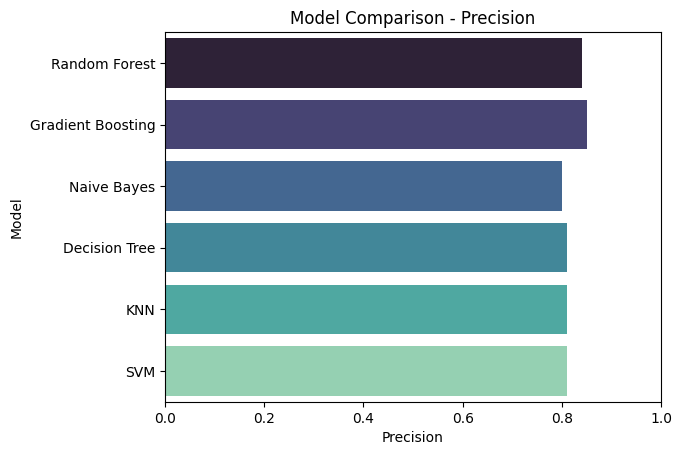

C:\Users\prash\AppData\Local\Temp\ipykernel_4744\3865556091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x=metric, y='Model', palette='mako')


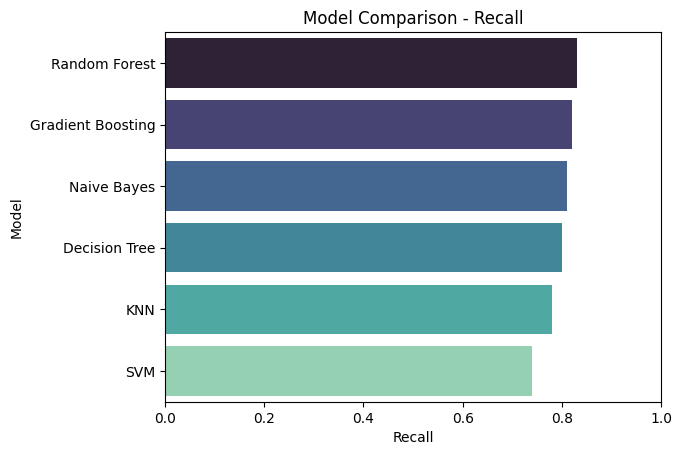

C:\Users\prash\AppData\Local\Temp\ipykernel_4744\3865556091.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x=metric, y='Model', palette='mako')


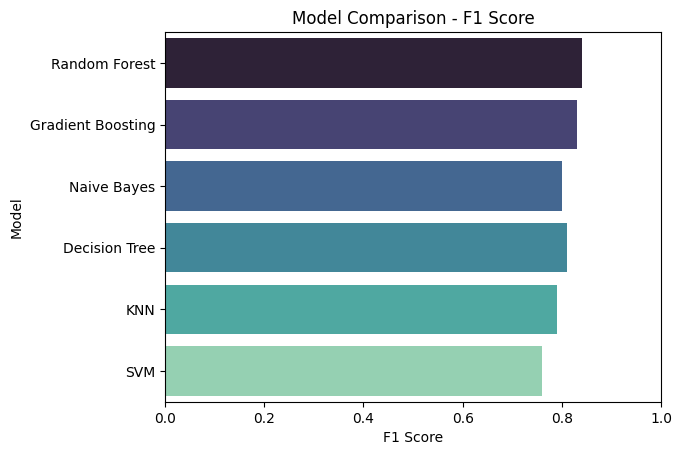

In [170]:
result_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']).sort_values(by='Accuracy', ascending=False)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure()
    sns.barplot(data=result_df, x=metric, y='Model', palette='mako')
    plt.title(f'Model Comparison - {metric}')
    plt.xlim(0, 1)
    plt.show()

In [171]:
result_df

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.83,0.84,0.83,0.84
4,Gradient Boosting,0.82,0.85,0.82,0.83
5,Naive Bayes,0.81,0.80,0.81,0.80
2,Decision Tree,0.80,0.81,0.80,0.81
0,KNN,0.78,0.81,0.78,0.79
1,SVM,0.74,0.81,0.74,0.76
